In [1]:
# Step 1: Read input data.

from __future__ import annotations

from pathlib import Path
import matplotlib as mpl
import numpy as np
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import lru_cache
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

def load_crosswalk(url: str, source: str):
    df = pd.read_csv(url, skiprows=10)
    df["source"] = source
    return df

@lru_cache(maxsize=None)
def get_label(uberon_id):
    iri = f'http://purl.obolibrary.org/obo/{uberon_id.replace(":", "_")}'
    url = "https://www.ebi.ac.uk/ols4/api/ontologies/uberon/terms"
    resp = requests.get(url, params={"iri": iri}, timeout=30)
    if resp.status_code == 200 and resp.json()["_embedded"]["terms"]:
        return resp.json()["_embedded"]["terms"][0]["label"]
    return None

LOCAL_CROSSWALKS = {
    "azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/azimuth/v1.4/assets/azimuth-crosswalk.csv",
    "celltypist": "https://cdn.humanatlas.io/digital-objects/ctann/celltypist/v1.3/assets/celltypist-crosswalk.csv",
    "deepcelltypes": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes/v1.2/assets/deepcelltypes-crosswalk.csv",
    "deepcelltypes_hubmap": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes-hubmap/v1.2/assets/deepcelltypes-hubmap-crosswalk.csv",
    "frmatch": "https://cdn.humanatlas.io/digital-objects/ctann/frmatch/v1.0/assets/frmatch-crosswalk.csv",
    "pan_human_azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/pan-human-azimuth/v1.2/assets/pan-human-azimuth-crosswalk.csv",
    "popv": "https://cdn.humanatlas.io/digital-objects/ctann/popv/v1.4/assets/popv-crosswalk.csv",
    "ribca": "https://cdn.humanatlas.io/digital-objects/ctann/ribca/v1.0/assets/ribca-crosswalk.csv",
    "stellar": "https://cdn.humanatlas.io/digital-objects/ctann/stellar/v1.0/assets/stellar-crosswalk.csv",
    "vccf": "https://cdn.humanatlas.io/digital-objects/ctann/vccf/v1.2/assets/vccf-crosswalk.csv",
}

SOURCE_LABELS = {
    "azimuth": "Azimuth",
    "celltypist": "CellTypist",
    "deepcelltypes": "DeepCell Types",
    "deepcelltypes_hubmap": "DeepCell Types-HuBMAP",
    "frmatch": "FR-Match",
    "pan_human_azimuth": "Pan-human Azimuth",
    "popv": "popV",
    "ribca": "RIBCA",
    "stellar": "STELLAR",
    "vccf": "CDE Spatial Omics",
}

# Figure / layout settings
SORT_MODE = "alphabetical"  # or "coverage"
FIGURE_FONT_SIZE = 10.5
ROW_SPACING_SCALE = 0.50
BOTTOM_SPACE_SCALE = 1.65
BOTTOM_LEGEND_SPACE_MM = 0
FIGURE_WIDTH_MM = 366.6
ORIGINAL_FIGURE_HEIGHT_MM = 135
ORIGINAL_BOTTOM_FRACTION = 0.39
ORIGINAL_TOP_FRACTION = 0.975
MM_TO_INCH = 1 / 25.4

# Always save figures into the project's shared vis directory, whether the
# notebook is run from the project root or from the notebook directory.
WORKING_DIRECTORY = Path.cwd()
OUTPUT_DIR = (
    WORKING_DIRECTORY / "vis"
    if (WORKING_DIRECTORY / "notebook").is_dir()
    else WORKING_DIRECTORY.parent / "vis"
)
OUTPUT_STEM = "crosswalk-fig-all-10-no-unspecified-log-colorbar-three-ticks-body-proper-first-source-matrices"


def load_crosswalk(path: str, source: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=10)
    df["source"] = source
    return df


def marker_area(count_like) -> np.ndarray:
    return 6 + 0.42 * np.asarray(count_like, dtype=float)


def format_legend_value(value: float) -> str:
    return f"{value:.0f}" if float(value).is_integer() else f"{value:.1f}"



mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_FONT_SIZE,
    "ytick.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": FIGURE_FONT_SIZE,
    "legend.title_fontsize": FIGURE_FONT_SIZE,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

print("Loading local crosswalk data...")
df_combined = pd.concat(
    [load_crosswalk(path, source) for source, path in LOCAL_CROSSWALKS.items()],
    ignore_index=True,
)

print(df_combined.head())

Loading local crosswalk data...


  Organ_Level        Organ_ID       Annotation_Label Annotation_Label_ID  \
0    Heart_L2  UBERON:0000948              Adipocyte          AZ:0000001   
1    Heart_L2  UBERON:0000948   Arterial Endothelial          AZ:0000002   
2    Heart_L2  UBERON:0000948   Atrial Cardiomyocyte          AZ:0000003   
3    Heart_L2  UBERON:0000948                      B          AZ:0000004   
4    Heart_L2  UBERON:0000948  Capillary Endothelial          AZ:0000005   

                         CL_Label       CL_ID         CL_Match   source  \
0                       adipocyte  CL:0000136  skos:exactMatch  azimuth   
1      endothelial cell of artery  CL:1000413  skos:exactMatch  azimuth   
2  regular atrial cardiac myocyte  CL:0002129  skos:exactMatch  azimuth   
3                          B cell  CL:0000236  skos:exactMatch  azimuth   
4      capillary endothelial cell  CL:0002144  skos:exactMatch  azimuth   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         Na

In [2]:
# Step 2: Get the source data used to create the figure.

df_size = (
    df_combined.groupby(["source", "Organ_ID"], as_index=False)["CL_Label"]
    .nunique()
    .rename(columns={"CL_Label": "n_unique_cell_label"})
)

mapping_keys = [
    "source",
    "Organ_ID",
    "Annotation_Label_ID",
    "CL_ID",
    "CL_Match",
]
df_mappings = df_combined.drop_duplicates(mapping_keys).copy()

df_match_quality = (
    df_mappings.groupby(["source", "Organ_ID"], as_index=False)
    .agg(
        n_mappings=("CL_Match", "size"),
        n_exact_matches=("CL_Match", lambda s: s.eq("skos:exactMatch").sum()),
        n_narrow_matches=("CL_Match", lambda s: s.eq("skos:narrowMatch").sum()),
        n_broad_matches=("CL_Match", lambda s: s.eq("skos:broadMatch").sum()),
    )
)
# Node color is the total number of standard SKOS match relationships.
df_match_quality["n_standard_skos_matches"] = (
    df_match_quality["n_exact_matches"]
    + df_match_quality["n_narrow_matches"]
    + df_match_quality["n_broad_matches"]
)

df_plot = df_size.merge(
    df_match_quality,
    on=["source", "Organ_ID"],
    how="left",
    validate="one_to_one",
)

df_plot["source"] = df_plot["source"].map(SOURCE_LABELS)
df_plot["source"] = pd.Categorical(
    df_plot["source"],
    categories=list(SOURCE_LABELS.values()),
    ordered=True,
)
# Resolve each identifier once, then reuse its human-readable label for all tools.
organ_labels = {
    organ_id: get_label(organ_id)
    for organ_id in df_plot["Organ_ID"].dropna().unique()
}
df_plot["organ_label"] = df_plot["Organ_ID"].map(organ_labels)
df_plot["organ_label"] = (
    df_plot["organ_label"]
    .fillna("Unspecified")
    .astype(str)
    .replace({"None": "Unspecified", "nan": "Unspecified"})
)
df_plot = df_plot.loc[df_plot["organ_label"] != "Unspecified"].copy()
print(df_plot)

tool_order = [
    label for label in SOURCE_LABELS.values()
    if label in set(df_plot["source"].astype(str))
]

organ_summary = (
    df_plot.groupby("organ_label", observed=True)
    .agg(
        n_tools=("source", "nunique"),
        total_cell_types=("n_unique_cell_label", "sum"),
    )
)

if SORT_MODE == "alphabetical":
    organ_order = sorted(organ_summary.index, key=str.casefold)
elif SORT_MODE == "coverage":
    organ_order = (
        organ_summary
        .sort_values(["n_tools", "total_cell_types"], ascending=[False, False], kind="stable")
        .index
        .tolist()
    )
else:
    raise ValueError("SORT_MODE must be 'alphabetical' or 'coverage'.")

# Keep the existing order of every other organ, but show whole-body coverage first.
if "body proper" in organ_order:
    organ_order = ["body proper"] + [organ for organ in organ_order if organ != "body proper"]

x_position = {organ: i for i, organ in enumerate(organ_order)}
y_position = {tool: i for i, tool in enumerate(tool_order)}

# Source data used by the figure: tools are rows and organs are columns.
match_rate_matrix = (
    df_plot.pivot(index="source", columns="organ_label", values="n_standard_skos_matches")
    .reindex(index=tool_order, columns=organ_order)
)
cell_type_matrix = (
    df_plot.pivot(index="source", columns="organ_label", values="n_unique_cell_label")
    .reindex(index=tool_order, columns=organ_order)
)
print("Match rate matrix (exact + narrow + broad matches)")
display(match_rate_matrix)
print("Cell type number matrix (unique #Cell types)")
display(cell_type_matrix)



               source        Organ_ID  n_unique_cell_label  n_mappings  \
0             Azimuth  UBERON:0000160                   12          12   
1             Azimuth  UBERON:0000178                   77          95   
3             Azimuth  UBERON:0000945                   16          16   
4             Azimuth  UBERON:0000948                   36          50   
5             Azimuth  UBERON:0000955                    9           9   
..                ...             ...                  ...         ...   
73  CDE Spatial Omics  UBERON:0002097                   20          39   
74  CDE Spatial Omics  UBERON:0002106                   20          27   
75  CDE Spatial Omics  UBERON:0002371                   49          61   
76  CDE Spatial Omics  UBERON:0002372                   71         112   
77  CDE Spatial Omics  UBERON:0002450                   29          36   

    n_exact_matches  n_narrow_matches  n_broad_matches  \
0                 3                 9                

organ_label,body proper,adipose tissue,adrenal gland,blood,blood vasculature,bone marrow,brain,decidua,esophagus,eye,...,small intestine,spleen,stomach,thymus,tongue,tonsil,trachea,urinary bladder,uterus,white adipose tissue
source,,,,,,,,,,,,,,,,,,,,,
Azimuth,NaN,93.0,12.0,95.0,NaN,52.0,9.0,NaN,NaN,16.0,...,NaN,9.0,16.0,5.0,NaN,NaN,NaN,NaN,NaN,61.0
CellTypist,NaN,NaN,NaN,27.0,NaN,45.0,NaN,NaN,NaN,NaN,...,134.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types-HuBMAP,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FR-Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pan-human Azimuth,446.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popV,NaN,12.0,NaN,20.0,14.0,15.0,NaN,NaN,NaN,30.0,...,17.0,25.0,NaN,23.0,11.0,NaN,18.0,15.0,13.0,NaN
RIBCA,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STELLAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell type number matrix (unique #Cell types)


organ_label,body proper,adipose tissue,adrenal gland,blood,blood vasculature,bone marrow,brain,decidua,esophagus,eye,...,small intestine,spleen,stomach,thymus,tongue,tonsil,trachea,urinary bladder,uterus,white adipose tissue
source,,,,,,,,,,,,,,,,,,,,,
Azimuth,NaN,55.0,12.0,77.0,NaN,46.0,9.0,NaN,NaN,16.0,...,NaN,9.0,16.0,5.0,NaN,NaN,NaN,NaN,NaN,55.0
CellTypist,NaN,NaN,NaN,27.0,NaN,44.0,NaN,NaN,NaN,NaN,...,133.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types-HuBMAP,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FR-Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pan-human Azimuth,440.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popV,NaN,12.0,NaN,20.0,14.0,15.0,NaN,NaN,NaN,30.0,...,17.0,25.0,NaN,23.0,11.0,NaN,18.0,15.0,13.0,NaN
RIBCA,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STELLAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Preparing figure, height=129.73 mm


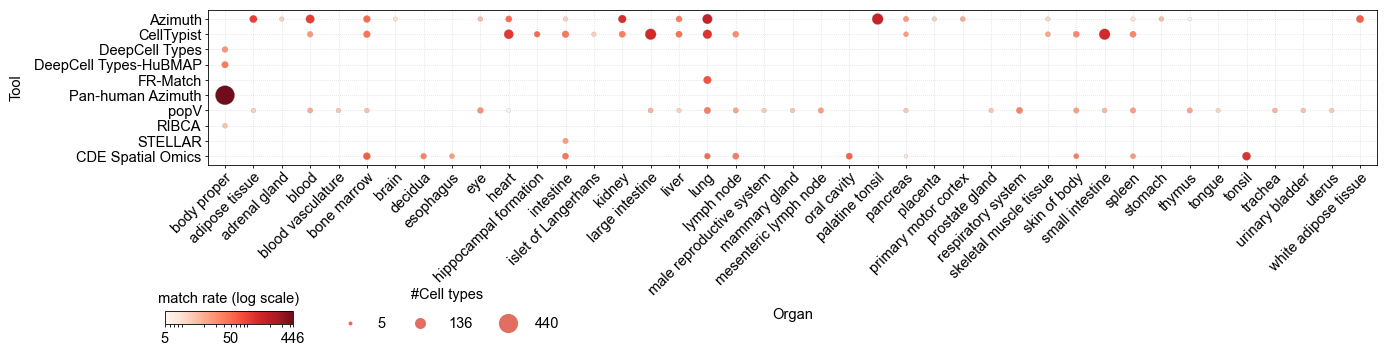

In [3]:
# Step 3: Create and save the figure.

bottom_margin_mm = (
    ORIGINAL_FIGURE_HEIGHT_MM * ORIGINAL_BOTTOM_FRACTION * BOTTOM_SPACE_SCALE
    + BOTTOM_LEGEND_SPACE_MM
)
top_margin_mm = ORIGINAL_FIGURE_HEIGHT_MM * (1 - ORIGINAL_TOP_FRACTION)
original_panel_height_mm = ORIGINAL_FIGURE_HEIGHT_MM * (ORIGINAL_TOP_FRACTION - ORIGINAL_BOTTOM_FRACTION)
panel_height_mm = original_panel_height_mm * ROW_SPACING_SCALE
figure_height_mm = bottom_margin_mm + panel_height_mm + top_margin_mm

figure_size = (
    FIGURE_WIDTH_MM * MM_TO_INCH,
    figure_height_mm * MM_TO_INCH,
)

print(f"Preparing figure, height={figure_height_mm:.2f} mm")
fig, ax = plt.subplots(figsize=figure_size)

match_sum_values = df_plot["n_standard_skos_matches"].astype(float)
match_sum_min = float(match_sum_values.min())
match_sum_max = float(match_sum_values.max())
# A logarithmic scale makes low match totals visually distinguishable.
norm = mpl.colors.LogNorm(
    vmin=match_sum_min,
    vmax=match_sum_max if match_sum_max > match_sum_min else match_sum_min + 1,
)
cmap = plt.cm.Reds
scatter = ax.scatter(
    df_plot["organ_label"].map(x_position),
    df_plot["source"].astype(str).map(y_position),
    s=marker_area(df_plot["n_unique_cell_label"]),
    c=df_plot["n_standard_skos_matches"],
    cmap=cmap,
    norm=norm,
    alpha=0.95,
    linewidths=0.15,
    edgecolors="#8a8a8a",
)

ax.set_xticks(np.arange(len(organ_order)))
ax.set_xticklabels(
    organ_order,
    rotation=45,
    ha="right",
    va="top",
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
    rotation_mode="anchor",
)

ax.set_yticks(np.arange(len(tool_order)))
ax.set_yticklabels(
    tool_order,
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
)

ax.invert_yaxis()
ax.set_xlabel("Organ", labelpad=7)
ax.set_ylabel("Tool", labelpad=7)
ax.set_xlim(-0.6, len(organ_order) - 0.4)
ax.set_ylim(len(tool_order) - 0.4, -0.6)
ax.set_axisbelow(True)
ax.grid(True, which="major", axis="both", color="#d9d9d9", linestyle=":", linewidth=0.55)

for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.6)

ax.tick_params(axis="x", pad=1, labelsize=FIGURE_FONT_SIZE)
ax.tick_params(axis="y", pad=2, labelsize=FIGURE_FONT_SIZE)

count_values = df_plot["n_unique_cell_label"].astype(float)
min_count = float(count_values.min())
max_count = float(count_values.max())
midpoint_target = (min_count + max_count) / 2
observed_counts = np.sort(count_values.dropna().unique())
midpoint_count = float(observed_counts[np.argmin(np.abs(observed_counts - midpoint_target))])
legend_values = [min_count, midpoint_count, max_count]
legend_handles = [
    ax.scatter([], [], s=marker_area(value), color="#d7301f", alpha=0.70, linewidths=0)
    for value in legend_values
]
legend_labels = [format_legend_value(v) for v in legend_values]

fig.subplots_adjust(
    left=0.15,
    right=0.96,
    top=1 - top_margin_mm / figure_height_mm,
    bottom=bottom_margin_mm / figure_height_mm,
)

ax_pos = ax.get_position()
cbar_width = 0.11 * ax_pos.width
cbar_height = 0.025
cbar_x = max(0.02, ax_pos.x0 - 0.03)
cbar_y = ax_pos.y0 - 0.31

cbar_ax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
# Keep only the requested low, middle, and high reference values.
match_sum_ticks = [match_sum_min, 50, match_sum_max]
cbar.set_ticks(match_sum_ticks)
cbar.ax.set_xticklabels([format_legend_value(value) for value in match_sum_ticks])
cbar.ax.set_title("match rate (log scale)", fontsize=FIGURE_FONT_SIZE, pad=6)

legend_x = cbar_x + cbar_width + 0.025
legend_y = ax_pos.y0 - 0.335
fig.legend(
    legend_handles,
    legend_labels,
    title="#Cell types",
    loc="lower left",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=fig.transFigure,
    frameon=False,
    borderaxespad=0,
    labelspacing=1.0,
    handleheight=1.0,
    handletextpad=0.9,
    ncol=3,
    columnspacing=1.4,
)

plt.show()